# Fine-tune and compare transformer intent classifiers

This notebook fine-tunes **ELECTRA-Small**, **MiniLM**, and **DistilBERT** on the same 27-intent dataset. It selects a model using validation macro-F1 (with latency as a tie-breaker), evaluates only that winner on the test split, and exports it to optimized FP32 and dynamically quantized INT8 ONNX.


## 1. Imports and configuration

Install the modeling environment with `uv sync --group modeling`, then select that environment as this notebook's kernel.

In [1]:
import gc
import json
import math
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from dotenv import load_dotenv
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
    set_seed,
)

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32 if DEVICE.type == "cuda" else 16
EVAL_BATCH_SIZE = BATCH_SIZE
MAX_EPOCHS = 5

env_file = Path.cwd() / ".env"
if not env_file.exists():
    env_file = Path.cwd().parent / ".env"
load_dotenv(env_file)

DATA_DIR = Path(os.environ["DATA_PATH"])
TRAINING_DIR = DATA_DIR / "models" / "transformer_candidates"
ARTIFACT_DIR = DATA_DIR / "models" / "intent_classifier_onnx"
TRAINING_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
set_seed(SEED)
print(f"Device: {DEVICE}; batch size: {BATCH_SIZE}")

/home/zain/Projects/Python/customer-service/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda; batch size: 32


## 2. Load and validate the prepared splits


In [2]:
split_names = ("train", "validation", "test")
splits = {
    name: pd.read_csv(
        DATA_DIR / f"{name}_split.csv",
        usecols=["instruction", "intent"],
        dtype={"instruction": str, "intent": str},
        keep_default_na=False,
    )
    for name in split_names
}

for name, frame in splits.items():
    assert list(frame.columns) == ["instruction", "intent"]
    assert frame.notna().all().all(), f"{name} contains missing values"
    frame["instruction"] = frame["instruction"].str.strip()
    frame["intent"] = frame["intent"].str.strip()
    assert not frame.eq("").any().any(), f"{name} contains blank values"

label_names = sorted(splits["train"]["intent"].unique())
label2id = {label: index for index, label in enumerate(label_names)}
id2label = {index: label for label, index in label2id.items()}

for name, frame in splits.items():
    assert sorted(frame["intent"].unique()) == label_names
    frame["label"] = frame["intent"].map(label2id).astype("int64")

assert len(label_names) == 27
pd.DataFrame({
    "rows": {name: len(frame) for name, frame in splits.items()},
    "intents": {name: frame["intent"].nunique() for name, frame in splits.items()},
})

,rows,intents
train,17216,27
validation,2460,27
test,4920,27


## 3. Preprocessing policy

Transformer preprocessing is deliberately light:

- Strip surrounding whitespace and encode the intent as an integer.
- Preserve punctuation, spelling mistakes, identifiers, numbers, and the original source text.
- Do **not** remove stop words, stem, lemmatize, or correct spelling.
- Let each checkpoint's uncased WordPiece tokenizer lowercase, split into subwords, add special tokens, create attention masks, and convert tokens to IDs.
- Calculate length from training data only. The maximum length is the next multiple of eight covering 99.9% of training examples, capped at 64.
- Truncate at that limit and dynamically pad each batch instead of padding the whole dataset.

Although these checkpoints use closely related vocabularies, each model must be paired with its own saved tokenizer.

In [3]:
MODEL_CONFIGS = {
    "electra-small": {
        "checkpoint": "google/electra-small-discriminator",
        "learning_rate": 5e-5,
    },
    "minilm": {
        "checkpoint": "microsoft/MiniLM-L12-H384-uncased",
        "learning_rate": 2e-5,
    },
    "distilbert": {
        "checkpoint": "distilbert/distilbert-base-uncased",
        "learning_rate": 2e-5,
    },
}

def json_default(value):
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, Path):
        return str(value)
    raise TypeError(f"Cannot serialize {type(value).__name__}")

def metric_values(labels, predictions):
    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro"),
        "weighted_f1": f1_score(labels, predictions, average="weighted"),
    }

def compute_metrics(eval_prediction):
    logits = eval_prediction.predictions
    if isinstance(logits, tuple):
        logits = logits[0]
    predictions = np.argmax(logits, axis=-1)
    return metric_values(eval_prediction.label_ids, predictions)

def choose_max_length(tokenizer, texts):
    lengths = []
    for start in range(0, len(texts), 512):
        encoded = tokenizer(
            texts[start:start + 512],
            add_special_tokens=True,
            padding=False,
            truncation=False,
            return_length=True,
        )
        lengths.extend(encoded["length"])
    percentile = float(np.percentile(lengths, 99.9))
    max_length = min(64, max(8, int(math.ceil(percentile / 8) * 8)))
    truncation_rate = float(np.mean(np.asarray(lengths) > max_length))
    return max_length, percentile, truncation_rate

class IntentDataset(torch.utils.data.Dataset):
    def __init__(self, frame, tokenizer, max_length):
        self.encodings = tokenizer(
            frame["instruction"].tolist(),
            truncation=True,
            max_length=max_length,
            padding=False,
        )
        self.labels = frame["label"].tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        item = {name: values[index] for name, values in self.encodings.items()}
        item["labels"] = self.labels[index]
        return item

def make_dataset(frame, tokenizer, max_length):
    return IntentDataset(frame, tokenizer, max_length)

## 4. Shared fine-tuning and timing pipeline

Every candidate sees identical rows and labels. The only intentional differences are its pretrained checkpoint, matching tokenizer, derived token limit, and planned learning rate.

In [4]:
def synchronize_device():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

def inference_latency_ms(model, tokenizer, texts, max_length, batch_size, repeats):
    examples = [texts[index % len(texts)] for index in range(batch_size)]
    inputs = tokenizer(
        examples,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )
    inputs = {name: tensor.to(model.device) for name, tensor in inputs.items()}
    model.eval()
    durations = []
    with torch.inference_mode():
        for _ in range(5):
            model(**inputs)
        synchronize_device()
        for _ in range(repeats):
            start = time.perf_counter()
            model(**inputs)
            synchronize_device()
            durations.append((time.perf_counter() - start) * 1000)
    return float(np.median(durations) / batch_size)

def evaluate_dataloader(model, dataloader):
    all_logits = []
    all_labels = []
    model.eval()
    with torch.inference_mode():
        for batch in dataloader:
            labels = batch.pop("labels").to(DEVICE)
            inputs = {key: value.to(DEVICE) for key, value in batch.items()}
            logits = model(**inputs).logits
            all_logits.append(logits.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    return np.concatenate(all_logits), np.concatenate(all_labels)

def train_candidate(name, config):
    set_seed(SEED)
    checkpoint = config["checkpoint"]
    candidate_dir = TRAINING_DIR / name
    final_dir = candidate_dir / "best"

    tokenizer = AutoTokenizer.from_pretrained(checkpoint, use_fast=True)
    max_length, length_p999, truncation_rate = choose_max_length(
        tokenizer, splits["train"]["instruction"].tolist()
    )
    train_dataset = make_dataset(splits["train"], tokenizer, max_length)
    validation_dataset = make_dataset(splits["validation"], tokenizer, max_length)

    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=len(label_names),
        label2id=label2id,
        id2label=id2label,
    ).to(DEVICE)
    parameter_count = sum(parameter.numel() for parameter in model.parameters())
    collator = DataCollatorWithPadding(
        tokenizer=tokenizer, pad_to_multiple_of=8, return_tensors="pt"
    )
    generator = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=collator,
        generator=generator,
    )
    validation_loader = DataLoader(
        validation_dataset,
        batch_size=EVAL_BATCH_SIZE,
        shuffle=False,
        collate_fn=collator,
    )
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config["learning_rate"], weight_decay=0.01
    )
    total_steps = len(train_loader) * MAX_EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * 0.1),
        num_training_steps=total_steps,
    )

    started = time.perf_counter()
    best_macro_f1 = -math.inf
    epochs_without_improvement = 0
    training_history = []
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        running_loss = 0.0
        for step, batch in enumerate(train_loader, start=1):
            batch = {key: value.to(DEVICE) for key, value in batch.items()}
            optimizer.zero_grad(set_to_none=True)
            output = model(**batch)
            output.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            running_loss += output.loss.item()
            if step % 100 == 0:
                print(f"{name} epoch {epoch} step {step}/{len(train_loader)} loss={running_loss / step:.4f}")

        epoch_logits, epoch_labels = evaluate_dataloader(model, validation_loader)
        epoch_predictions = epoch_logits.argmax(axis=1)
        epoch_metrics = metric_values(epoch_labels, epoch_predictions)
        epoch_record = {
            "epoch": epoch,
            "train_loss": running_loss / len(train_loader),
            **epoch_metrics,
        }
        training_history.append(epoch_record)
        print(f"{name} epoch {epoch}: {epoch_record}")

        if epoch_metrics["macro_f1"] > best_macro_f1 + 1e-6:
            best_macro_f1 = epoch_metrics["macro_f1"]
            epochs_without_improvement = 0
            model.save_pretrained(final_dir)
            tokenizer.save_pretrained(final_dir)
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= 1:
                print(f"Early stopping {name} after epoch {epoch}.")
                break

    training_seconds = time.perf_counter() - started
    model = AutoModelForSequenceClassification.from_pretrained(final_dir).to(DEVICE)
    validation_logits, validation_labels = evaluate_dataloader(model, validation_loader)
    validation_predictions = validation_logits.argmax(axis=1)
    metrics = metric_values(validation_labels, validation_predictions)

    size_mb = sum(path.stat().st_size for path in final_dir.rglob("*") if path.is_file()) / 1e6
    latency_1 = inference_latency_ms(
        model, tokenizer, splits["validation"]["instruction"].tolist(), max_length, 1, 50
    )
    latency_32 = inference_latency_ms(
        model, tokenizer, splits["validation"]["instruction"].tolist(), max_length, 32, 20
    )

    summary = {
        "name": name,
        "checkpoint": checkpoint,
        "best_checkpoint": str(final_dir),
        "learning_rate": config["learning_rate"],
        "max_length": max_length,
        "training_length_p999": length_p999,
        "training_truncation_rate": truncation_rate,
        "parameter_count": parameter_count,
        "model_size_mb": size_mb,
        "training_seconds": training_seconds,
        "latency_batch_1_ms_per_item": latency_1,
        "latency_batch_32_ms_per_item": latency_32,
        **metrics,
    }
    state = {
        "summary": summary,
        "validation_predictions": validation_predictions,
        "validation_labels": validation_labels,
        "classification_report": classification_report(
            validation_labels,
            validation_predictions,
            labels=np.arange(len(label_names)),
            target_names=label_names,
            output_dict=True,
            zero_division=0,
        ),
        "confusion_matrix": confusion_matrix(
            validation_labels, validation_predictions, labels=np.arange(len(label_names))
        ),
        "training_history": training_history,
    }
    del model, optimizer, scheduler, train_loader, validation_loader
    del train_dataset, validation_dataset
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return state

## 5. Train all three candidates

This is the expensive cell. On a CPU, training all three models can take a substantial amount of time. Completed candidate checkpoints are written beneath `data/models/transformer_candidates/`.

> Transformers will report that each classification head is newly initialized. That message is expected: the downloaded checkpoints contain pretrained language encoders, while this notebook creates and trains a new 27-class output head.

In [5]:
candidate_states = {}
for model_name, model_config in MODEL_CONFIGS.items():
    print(f"\n{'=' * 80}\nTraining {model_name}: {model_config['checkpoint']}")
    candidate_states[model_name] = train_candidate(model_name, model_config)

comparison = (
    pd.DataFrame([state["summary"] for state in candidate_states.values()])
    .sort_values(["macro_f1", "latency_batch_1_ms_per_item"], ascending=[False, True])
    .reset_index(drop=True)
)
comparison


Training electra-small: google/electra-small-discriminator


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-small-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


electra-small epoch 1 step 100/538 loss=3.2895
electra-small epoch 1 step 200/538 loss=3.2278
electra-small epoch 1 step 300/538 loss=3.0624
electra-small epoch 1 step 400/538 loss=2.8116
electra-small epoch 1 step 500/538 loss=2.5321
electra-small epoch 1: {'epoch': 1, 'train_loss': 2.4292173293665, 'accuracy': 0.891869918699187, 'macro_f1': 0.8431469689259562, 'weighted_f1': 0.8653266486045299}
electra-small epoch 2 step 100/538 loss=0.8014
electra-small epoch 2 step 200/538 loss=0.6614
electra-small epoch 2 step 300/538 loss=0.5502
electra-small epoch 2 step 400/538 loss=0.4646
electra-small epoch 2 step 500/538 loss=0.3981
electra-small epoch 2: {'epoch': 2, 'train_loss': 0.3770676783137162, 'accuracy': 0.9951219512195122, 'macro_f1': 0.9947245706697514, 'weighted_f1': 0.9951150761368618}
electra-small epoch 3 step 100/538 loss=0.0803
electra-small epoch 3 step 200/538 loss=0.0692
electra-small epoch 3 step 300/538 loss=0.0636
electra-small epoch 3 step 400/538 loss=0.0574
electra-

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/MiniLM-L12-H384-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


minilm epoch 1 step 100/538 loss=3.2948
minilm epoch 1 step 200/538 loss=3.2537
minilm epoch 1 step 300/538 loss=3.0729
minilm epoch 1 step 400/538 loss=2.8669
minilm epoch 1 step 500/538 loss=2.6673
minilm epoch 1: {'epoch': 1, 'train_loss': 2.5960945351859452, 'accuracy': 0.8939024390243903, 'macro_f1': 0.8457904724323249, 'weighted_f1': 0.8694565847165509}
minilm epoch 2 step 100/538 loss=1.4453
minilm epoch 2 step 200/538 loss=1.3160
minilm epoch 2 step 300/538 loss=1.2024
minilm epoch 2 step 400/538 loss=1.1006
minilm epoch 2 step 500/538 loss=1.0078
minilm epoch 2: {'epoch': 2, 'train_loss': 0.9754336331745949, 'accuracy': 0.9930894308943089, 'macro_f1': 0.9924088659193896, 'weighted_f1': 0.9930886894241421}
minilm epoch 3 step 100/538 loss=0.4715
minilm epoch 3 step 200/538 loss=0.4309
minilm epoch 3 step 300/538 loss=0.3960
minilm epoch 3 step 400/538 loss=0.3666
minilm epoch 3 step 500/538 loss=0.3413
minilm epoch 3: {'epoch': 3, 'train_loss': 0.3329848953173063, 'accuracy': 0

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


distilbert epoch 1 step 100/538 loss=3.2747
distilbert epoch 1 step 200/538 loss=2.9853
distilbert epoch 1 step 300/538 loss=2.4453
distilbert epoch 1 step 400/538 loss=1.9547
distilbert epoch 1 step 500/538 loss=1.5978
distilbert epoch 1: {'epoch': 1, 'train_loss': 1.492498626205447, 'accuracy': 0.9934959349593496, 'macro_f1': 0.9932656912833346, 'weighted_f1': 0.9935022459263474}
distilbert epoch 2 step 100/538 loss=0.0606
distilbert epoch 2 step 200/538 loss=0.0536
distilbert epoch 2 step 300/538 loss=0.0454
distilbert epoch 2 step 400/538 loss=0.0401
distilbert epoch 2 step 500/538 loss=0.0364
distilbert epoch 2: {'epoch': 2, 'train_loss': 0.035471137289345596, 'accuracy': 0.9963414634146341, 'macro_f1': 0.9961762322139094, 'weighted_f1': 0.9963423636006031}
distilbert epoch 3 step 100/538 loss=0.0102
distilbert epoch 3 step 200/538 loss=0.0107
distilbert epoch 3 step 300/538 loss=0.0109
distilbert epoch 3 step 400/538 loss=0.0100
distilbert epoch 3 step 500/538 loss=0.0092
distilb

,name,checkpoint,best_checkpoint,learning_rate,max_length,training_length_p999,training_truncation_rate,parameter_count,model_size_mb,training_seconds,latency_batch_1_ms_per_item,latency_batch_32_ms_per_item,accuracy,macro_f1,weighted_f1
0,distilbert,distilbert/distilbert-base-uncased,/home/zain/Projects/Python/customer-service/da...,0.00002,24,23.0,0.000116,66974235,268.855938,374.902783,23.558679,0.704790,0.996341,0.996176,0.996342
1,minilm,microsoft/MiniLM-L12-H384-uncased,/home/zain/Projects/Python/customer-service/da...,0.00002,24,23.0,0.000116,33370395,134.451502,380.480139,28.862440,1.070584,0.995935,0.995445,0.995939
2,electra-small,google/electra-small-discriminator,/home/zain/Projects/Python/customer-service/da...,0.00005,24,23.0,0.000116,13555739,55.193606,115.019679,7.177021,0.264379,0.995935,0.995396,0.995939


Selected electra-small: macro-F1=0.9954, batch-1 latency=7.18 ms


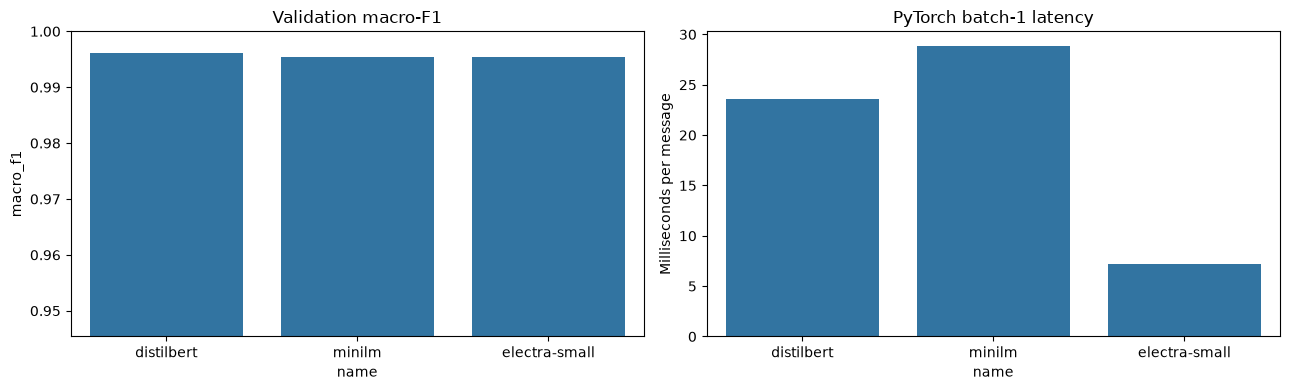

In [6]:
best_macro_f1 = comparison["macro_f1"].max()
near_best = comparison[comparison["macro_f1"] >= best_macro_f1 - 0.005]
winner = near_best.sort_values("latency_batch_1_ms_per_item").iloc[0]
winner_name = winner["name"]
winner_checkpoint = Path(winner["best_checkpoint"])
winner_max_length = int(winner["max_length"])
print(f"Selected {winner_name}: macro-F1={winner['macro_f1']:.4f}, batch-1 latency={winner['latency_batch_1_ms_per_item']:.2f} ms")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=comparison, x="name", y="macro_f1", ax=axes[0])
sns.barplot(data=comparison, x="name", y="latency_batch_1_ms_per_item", ax=axes[1])
axes[0].set_title("Validation macro-F1")
axes[0].set_ylim(max(0, comparison["macro_f1"].min() - 0.05), 1.0)
axes[1].set_title("PyTorch batch-1 latency")
axes[1].set_ylabel("Milliseconds per message")
plt.tight_layout()
plt.show()

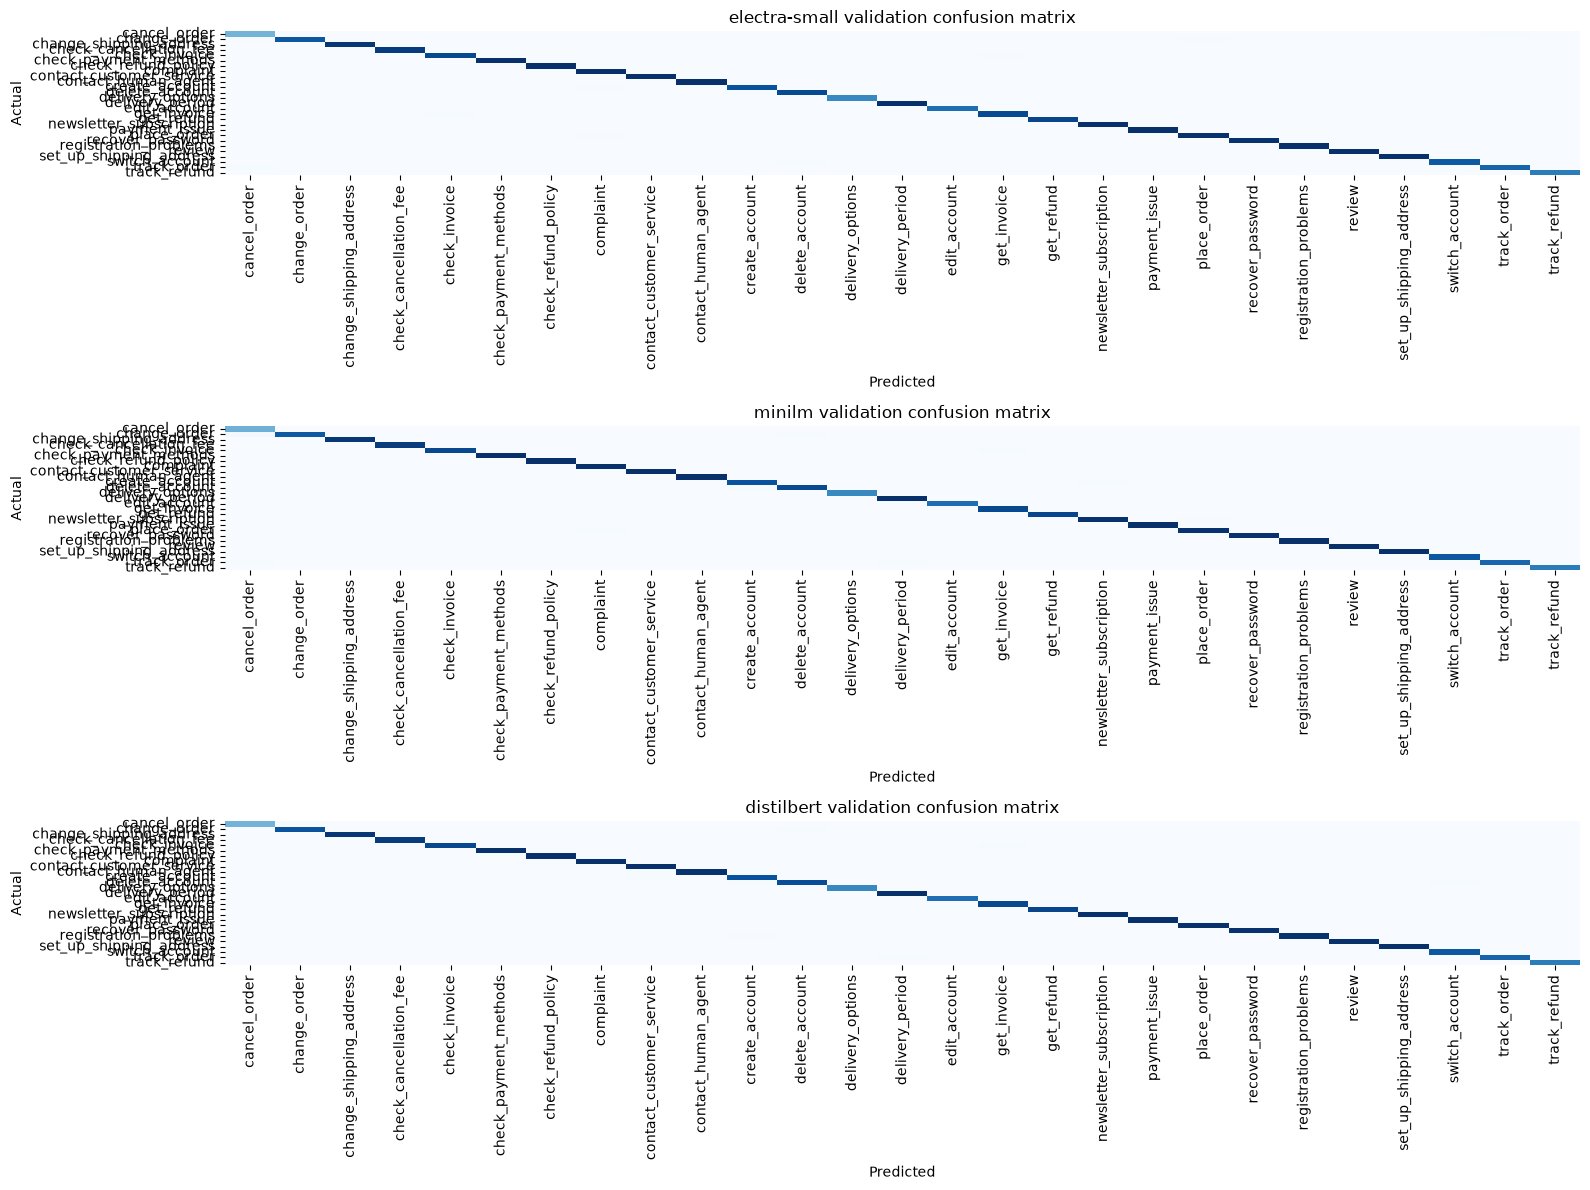

,precision,recall,f1-score,support
cancel_order,0.960000,0.979592,0.969697,49.000000
change_order,1.000000,0.977011,0.988372,87.000000
change_shipping_address,1.000000,1.000000,1.000000,97.000000
check_cancellation_fee,1.000000,1.000000,1.000000,95.000000
check_invoice,0.989130,0.989130,0.989130,92.000000
check_payment_methods,1.000000,1.000000,1.000000,100.000000
check_refund_policy,1.000000,1.000000,1.000000,100.000000
complaint,0.980392,1.000000,0.990099,100.000000
contact_customer_service,1.000000,1.000000,1.000000,100.000000
contact_human_agent,1.000000,1.000000,1.000000,100.000000


In [7]:
fig, axes = plt.subplots(len(candidate_states), 1, figsize=(16, 12))
for axis, (name, state) in zip(axes, candidate_states.items()):
    sns.heatmap(
        state["confusion_matrix"],
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names,
        ax=axis,
        cbar=False,
    )
    axis.set_title(f"{name} validation confusion matrix")
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")
plt.tight_layout()
plt.show()

winner_report = pd.DataFrame(candidate_states[winner_name]["classification_report"]).T
winner_report

## 6. Export the validation winner to ONNX

The winner is exported with ONNX Runtime O2 graph optimizations. A second copy uses dynamic per-channel INT8 quantization for this machine's AVX2-capable CPU.

In [8]:
import onnx
from onnxruntime.quantization import quantize_dynamic
from optimum.exporters.onnx import main_export
from optimum.onnxruntime import ORTModelForSequenceClassification
from optimum.onnxruntime.configuration import AutoQuantizationConfig, ORTConfig
from transformers import AutoConfig

FP32_DIR = ARTIFACT_DIR / "fp32"
INT8_DIR = ARTIFACT_DIR / "int8"
FP32_DIR.mkdir(parents=True, exist_ok=True)
INT8_DIR.mkdir(parents=True, exist_ok=True)

winner_tokenizer = AutoTokenizer.from_pretrained(winner_checkpoint, use_fast=True)
winner_tokenizer.save_pretrained(ARTIFACT_DIR)
main_export(
    model_name_or_path=str(winner_checkpoint),
    output=FP32_DIR,
    task="text-classification",
    optimize="O2",
    do_validation=True,
)
fp32_files = sorted(FP32_DIR.glob("*.onnx"))
assert len(fp32_files) == 1, f"Expected one FP32 ONNX file, found {fp32_files}"
fp32_file = fp32_files[0]

quantization_config = AutoQuantizationConfig.avx2(
    is_static=False, per_channel=True, reduce_range=False
)
int8_file = INT8_DIR / f"{fp32_file.stem}_quantized.onnx"
quantize_dynamic(
    model_input=fp32_file,
    model_output=int8_file,
    op_types_to_quantize=quantization_config.operators_to_quantize,
    per_channel=quantization_config.per_channel,
    reduce_range=quantization_config.reduce_range,
    weight_type=quantization_config.weights_dtype,
    nodes_to_quantize=quantization_config.nodes_to_quantize,
    nodes_to_exclude=quantization_config.nodes_to_exclude,
    extra_options={
        "WeightSymmetric": quantization_config.weights_symmetric,
        "ActivationSymmetric": quantization_config.activations_symmetric,
        # O2 creates com.microsoft fused ops whose outputs ONNX cannot infer.
        "DefaultTensorType": onnx.TensorProto.FLOAT,
    },
)
AutoConfig.from_pretrained(FP32_DIR).save_pretrained(INT8_DIR)
ORTConfig(quantization=quantization_config).save_pretrained(INT8_DIR)
print(f"FP32: {fp32_file} ({fp32_file.stat().st_size / 1e6:.1f} MB)")
print(f"INT8: {int8_file} ({int8_file.stat().st_size / 1e6:.1f} MB)")

`torch_dtype` is deprecated! Use `dtype` instead!
symbolic shape inference disabled or failed.
		-[x] values not close enough, max diff: 1.7762184143066406e-05 (atol: 1e-05)
The ONNX export succeeded with the warning: The maximum absolute difference between the output of the reference model and the ONNX exported model is not within the set tolerance 1e-05:
- logits: max diff = 1.7762184143066406e-05.
 The exported model was saved at: /home/zain/Projects/Python/customer-service/data/models/intent_classifier_onnx/fp32


FP32: /home/zain/Projects/Python/customer-service/data/models/intent_classifier_onnx/fp32/model.onnx (54.3 MB)
INT8: /home/zain/Projects/Python/customer-service/data/models/intent_classifier_onnx/int8/model_quantized.onnx (14.0 MB)


## 7. Validate ONNX parity and choose the deployment precision

FP32 must reproduce every PyTorch validation label. INT8 is accepted only when it agrees with FP32 on at least 99% of validation examples and loses no more than 0.5 percentage points of validation macro-F1.

In [9]:
def batched_logits(model, tokenizer, texts, max_length, batch_size=128):
    output = []
    for start in range(0, len(texts), batch_size):
        inputs = tokenizer(
            texts[start:start + batch_size],
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        target_device = getattr(model, "device", torch.device("cpu"))
        inputs = {name: tensor.to(target_device) for name, tensor in inputs.items()}
        with torch.inference_mode():
            output.append(model(**inputs).logits.detach().cpu().numpy())
    return np.concatenate(output)

validation_texts = splits["validation"]["instruction"].tolist()
validation_labels = splits["validation"]["label"].to_numpy()
pytorch_model = AutoModelForSequenceClassification.from_pretrained(winner_checkpoint).to(DEVICE)
fp32_model = ORTModelForSequenceClassification.from_pretrained(
    FP32_DIR, file_name=fp32_file.name
)
int8_model = ORTModelForSequenceClassification.from_pretrained(
    INT8_DIR, file_name=int8_file.name
)

pytorch_logits = batched_logits(
    pytorch_model, winner_tokenizer, validation_texts, winner_max_length
)
fp32_logits = batched_logits(
    fp32_model, winner_tokenizer, validation_texts, winner_max_length
)
int8_logits = batched_logits(
    int8_model, winner_tokenizer, validation_texts, winner_max_length
)
pytorch_predictions = pytorch_logits.argmax(axis=1)
fp32_predictions = fp32_logits.argmax(axis=1)
int8_predictions = int8_logits.argmax(axis=1)

fp32_label_agreement = float(np.mean(fp32_predictions == pytorch_predictions))
fp32_max_logit_difference = float(np.max(np.abs(fp32_logits - pytorch_logits)))
assert fp32_label_agreement == 1.0, "FP32 ONNX labels do not fully match PyTorch"

fp32_metrics = metric_values(validation_labels, fp32_predictions)
int8_metrics = metric_values(validation_labels, int8_predictions)
int8_label_agreement = float(np.mean(int8_predictions == fp32_predictions))
int8_macro_f1_drop = fp32_metrics["macro_f1"] - int8_metrics["macro_f1"]
use_int8 = int8_label_agreement >= 0.99 and int8_macro_f1_drop <= 0.005

deployment_precision = "int8" if use_int8 else "fp32"
deployment_file = int8_file if use_int8 else fp32_file
deployment_model = int8_model if use_int8 else fp32_model
pd.DataFrame([
    {"format": "fp32", **fp32_metrics, "agreement_with_reference": fp32_label_agreement},
    {"format": "int8", **int8_metrics, "agreement_with_reference": int8_label_agreement},
]), deployment_precision, fp32_max_logit_difference

(  format  accuracy  macro_f1  weighted_f1  agreement_with_reference
 0   fp32  0.995935  0.995396     0.995939                   1.00000
 1   int8  0.996748  0.996425     0.996751                   0.99878,
 'int8',
 1.8835067749023438e-05)

## 8. Final test evaluation and artifact manifest

This is the first and only model evaluation on the test split.

In [10]:
test_texts = splits["test"]["instruction"].tolist()
test_labels = splits["test"]["label"].to_numpy()
test_logits = batched_logits(
    deployment_model, winner_tokenizer, test_texts, winner_max_length
)
test_predictions = test_logits.argmax(axis=1)
test_metrics = metric_values(test_labels, test_predictions)
test_report = classification_report(
    test_labels,
    test_predictions,
    labels=np.arange(len(label_names)),
    target_names=label_names,
    output_dict=True,
    zero_division=0,
)

labels_payload = {"label2id": label2id, "id2label": {str(k): v for k, v in id2label.items()}}
(ARTIFACT_DIR / "labels.json").write_text(
    json.dumps(labels_payload, indent=2), encoding="utf-8"
)
comparison_payload = {
    "candidates": [state["summary"] for state in candidate_states.values()],
    "winner": winner_name,
    "validation_classification_reports": {
        name: state["classification_report"] for name, state in candidate_states.items()
    },
    "validation_confusion_matrices": {
        name: state["confusion_matrix"] for name, state in candidate_states.items()
    },
    "winner_validation_report": candidate_states[winner_name]["classification_report"],
    "onnx_validation": {
        "fp32": fp32_metrics,
        "int8": int8_metrics,
        "fp32_label_agreement": fp32_label_agreement,
        "fp32_max_logit_difference": fp32_max_logit_difference,
        "int8_label_agreement": int8_label_agreement,
        "int8_macro_f1_drop": int8_macro_f1_drop,
    },
    "test_metrics": test_metrics,
    "test_classification_report": test_report,
}
(ARTIFACT_DIR / "comparison_metrics.json").write_text(
    json.dumps(comparison_payload, indent=2, default=json_default), encoding="utf-8"
)
deployment_manifest = {
    "model_name": winner_name,
    "source_checkpoint": MODEL_CONFIGS[winner_name]["checkpoint"],
    "precision": deployment_precision,
    "model_path": str(deployment_file.relative_to(ARTIFACT_DIR)),
    "tokenizer_path": ".",
    "labels_path": "labels.json",
    "max_length": winner_max_length,
    "input": "one non-empty English customer message or a list of messages",
    "output": "one intent label per message",
}
(ARTIFACT_DIR / "deployment.json").write_text(
    json.dumps(deployment_manifest, indent=2), encoding="utf-8"
)
print(json.dumps({"test_metrics": test_metrics, "deployment": deployment_manifest}, indent=2))

{
  "test_metrics": {
    "accuracy": 0.9979674796747967,
    "macro_f1": 0.9974716329429417,
    "weighted_f1": 0.9979719017054005
  },
  "deployment": {
    "model_name": "electra-small",
    "source_checkpoint": "google/electra-small-discriminator",
    "precision": "int8",
    "model_path": "int8/model_quantized.onnx",
    "tokenizer_path": ".",
    "labels_path": "labels.json",
    "max_length": 24,
    "input": "one non-empty English customer message or a list of messages",
    "output": "one intent label per message"
  }
}


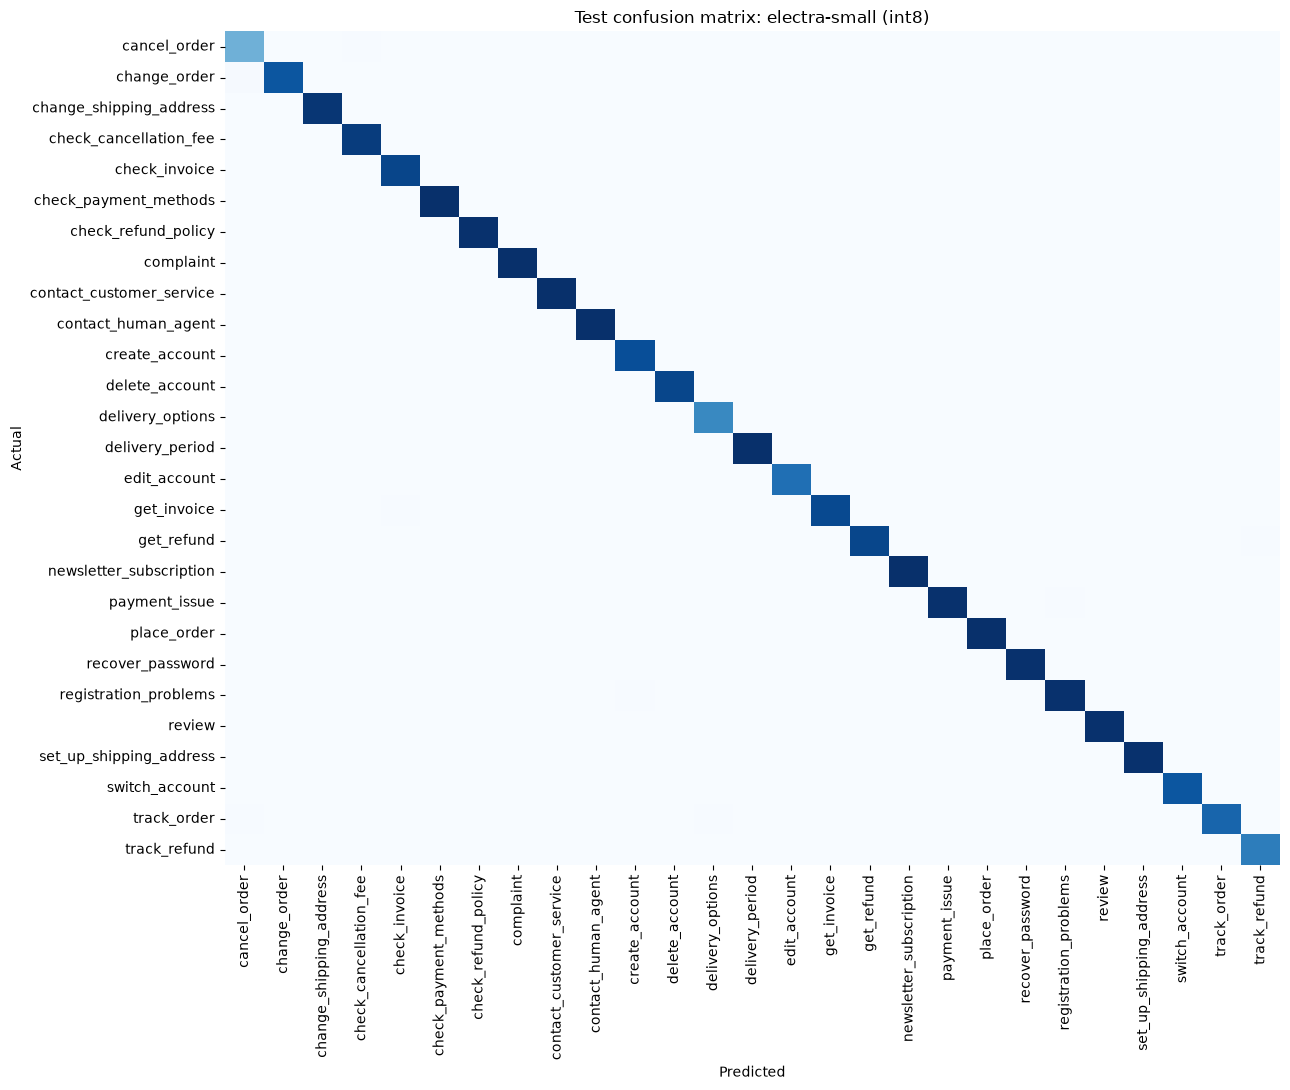

,precision,recall,f1-score,support
cancel_order,0.960784,0.989899,0.975124,99.000000
change_order,1.000000,0.982759,0.991304,174.000000
change_shipping_address,1.000000,1.000000,1.000000,195.000000
check_cancellation_fee,0.994764,1.000000,0.997375,190.000000
check_invoice,0.994595,1.000000,0.997290,184.000000
check_payment_methods,1.000000,1.000000,1.000000,200.000000
check_refund_policy,1.000000,1.000000,1.000000,199.000000
complaint,1.000000,1.000000,1.000000,200.000000
contact_customer_service,1.000000,1.000000,1.000000,200.000000
contact_human_agent,1.000000,1.000000,1.000000,200.000000


In [11]:
test_matrix = confusion_matrix(
    test_labels, test_predictions, labels=np.arange(len(label_names))
)
plt.figure(figsize=(13, 11))
sns.heatmap(
    test_matrix, cmap="Blues", xticklabels=label_names, yticklabels=label_names, cbar=False
)
plt.title(f"Test confusion matrix: {winner_name} ({deployment_precision})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
pd.DataFrame(test_report).T

## 9. Cold-load the artifact and predict labels

The inference helper loads only files from the exported artifact. It returns labels—not confidence scores—and rejects blank input.

In [12]:
def load_intent_classifier(artifact_dir):
    artifact_dir = Path(artifact_dir)
    manifest = json.loads((artifact_dir / "deployment.json").read_text(encoding="utf-8"))
    labels = json.loads((artifact_dir / manifest["labels_path"]).read_text(encoding="utf-8"))
    model_path = artifact_dir / manifest["model_path"]
    tokenizer = AutoTokenizer.from_pretrained(artifact_dir / manifest["tokenizer_path"], use_fast=True)
    model = ORTModelForSequenceClassification.from_pretrained(
        model_path.parent, file_name=model_path.name
    )
    return model, tokenizer, labels["id2label"], int(manifest["max_length"])

def predict_intents(texts, artifact_dir=ARTIFACT_DIR):
    is_single = isinstance(texts, str)
    values = [texts] if is_single else list(texts)
    if not values or any(not isinstance(text, str) or not text.strip() for text in values):
        raise ValueError("Every input must be a non-empty string.")
    values = [text.strip() for text in values]
    model, tokenizer, exported_id2label, max_length = load_intent_classifier(artifact_dir)
    logits = batched_logits(model, tokenizer, values, max_length)
    labels = [exported_id2label[str(index)] for index in logits.argmax(axis=1)]
    return labels[0] if is_single else labels

examples = [
    "Where is my order ORD-123456?",
    "I cant log into my acount",
    "Please unsubscribe me from the newsletter!",
]
print(predict_intents(examples))
assert isinstance(predict_intents(examples[0]), str)
assert len(predict_intents(examples)) == len(examples)
try:
    predict_intents("   ")
except ValueError:
    print("Blank-input rejection passed.")
else:
    raise AssertionError("Blank input should be rejected")

['track_order', 'create_account', 'newsletter_subscription']
Blank-input rejection passed.
